# RETFound on MMRDR-CFP — Reproducing the Paper Baseline (v2)

**Target (paper Table 3, RETFound / MMRDR-CFP, setting "FT" = full fine-tune, inputs resized to 512x512):**

| Metric | Paper |
|---|---|
| Grade accuracy `AccG` | **0.822** |
| Grade F1 `F1G` | **0.714** |
| Lesion accuracy `AccL` | **0.951** |
| Lesion F1 `F1L` | **0.682** |

---

## Why the previous run only reached 0.665 — three real bugs

The earlier notebook (`findings/train_retfound.ipynb`) reported 66.5% grade accuracy. That number is
**not a RETFound result**. Three defects were found by auditing the code:

**1. The pretrained weights never loaded — only 4 of 294 tensors transferred.**
RETFound ships an MAE ViT-Large checkpoint in *timm* layout (`blocks.*`, `cls_token`, `pos_embed`).
The old notebook hand-remapped those names onto *torchvision* `vit_l_16` and got it wrong:

| checkpoint key | old notebook mapped to | torchvision actually needs |
|---|---|---|
| `blocks.{i}.attn.qkv.weight` | `encoder.layers.{i}...` | `encoder.layers.encoder_layer_{i}.self_attention.in_proj_weight` |
| `cls_token` | *(never renamed)* | `class_token` |
| `pos_embed` | *(never renamed)* | `encoder.pos_embedding` |

`load_state_dict(..., strict=False)` silently discarded all 290 mismatches, and the cell printed an
unconditional `"Checkpoint mapping complete"`. **The model was a randomly-initialised ViT-Large** —
exactly the regime where ViT-L collapses on ~9k images.

**2. The freezing code was a no-op.** It did `int(name.split(".")[3])`, but for
`encoder.layers.encoder_layer_0.ln_1.weight` position 3 is the string `"ln_1"`, so `int()` raised
`ValueError` and hit `continue` every time. **Nothing was frozen.** (So the answer to *"how do you know
you froze the first layers?"* was: we didn't — and this notebook now *proves* the state of every layer.)

**3. Protocol problems.** No LR scheduler or warmup, no random seed, an unstratified random split, the
test set doubled as the validation set, and accuracy-only metrics (no kappa / F1 / AUC).

---

## What this notebook does differently

| Fix | How |
|---|---|
| Weights actually load | Build the ViT with **timm**, whose parameter names match RETFound natively — no remapping. Then **hard-fail** unless >=95% of `blocks.*` match. |
| Prove it loaded | Three independent checks: key-match report, a per-block weight-statistics table vs. a fresh random model, and a frozen-backbone linear probe. |
| Prove what is trainable | A printed per-layer-group table of `requires_grad`, parameter counts, and effective LR. |
| Match the paper | **512x512**, **full** fine-tune, the dataset's **official `tr`/`ts` split**. |
| Proper recipe | Layer-wise LR decay (0.65), cosine schedule + warmup, drop-path 0.2, label smoothing, fixed seed. |
| Proper metrics | The paper's four numbers **plus** quadratic kappa, AUROC, PR-AUC, per-rare recall, confusion matrix, bootstrap CIs. |
| Survive Kaggle | Per-epoch checkpoint -> Kaggle Dataset backup, auto-resume, wall-clock budget guard. |

## Method

- **Backbone** RETFound (MAE-pretrained ViT-Large/16), loaded into `timm` at `img_size=512`
  with the position embedding interpolated from the 224 grid (197 tokens) to the 512 grid (1025 tokens).
- **Pooling** `global_pool='avg'` + `fc_norm` — this is what RETFound's own `models_vit.py` does
  (mean-pool the patch tokens rather than use CLS).
- **Heads** two linear heads on the 1024-d feature: grade (5-way softmax), lesion (7-way multi-label).
- **Loss** `CrossEntropy(label_smoothing=0.1)` + `1.0 * BCEWithLogits`, **unweighted** so the accuracy
  numbers stay comparable to the paper.
- **Split** official: image basenames `tr*` (8,893) train, `ts*` (2,225) test. A stratified 15% of the
  `tr` portion is carved off as validation; `ts` is touched **only once**, at the end.

In [80]:
# ==============================================================================
# 0. Environment probe + installs
# ==============================================================================
# ORDER MATTERS: import torch FULLY before timm/torchvision.
# Recent timm versions import torch._dynamo at module-import time (via naflexvit's
# @disable_compiler). If timm is imported first, that re-enters a partially
# initialised torch and raises the confusing:
#     AttributeError: module 'torch' has no attribute '_utils'
import os, sys, subprocess, platform
import torch                      # <-- must come first
import torch._utils               # force-bind: a failed 3rd-party import can leave this unresolved
import torchvision

# Guard: if an earlier failed import corrupted torch in THIS session, torch._utils stays
# unresolved and the failure resurfaces much later inside torch.load(). Catch it here.
try:
    _ = torch._utils._element_size(torch.float32)
except AttributeError as _e:
    raise RuntimeError(
        "\n" + "=" * 78 +
        "\ntorch is in a BROKEN state in this session (torch._utils is unresolved).\n"
        "This happens after an earlier import error and does NOT heal by re-running cells.\n\n"
        "FIX:  Run -> Restart Session,  then  Run All.\n"
        + "=" * 78) from _e

print("Python      :", sys.version.split()[0], "on", platform.system())
print("PyTorch     :", torch.__version__)
print("torchvision :", torchvision.__version__)


def _pip(*args):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])
        return True
    except Exception as e:
        print(f"[warn] pip install {args} failed: {e}")
        return False


def _import_timm():
    '''Import timm, pinning a torch-compatible version if the installed one is broken.'''
    try:
        import timm
        return timm
    except Exception as e:
        print("[timm] import failed:", str(e)[:180])
        print("[timm] installing a pinned, compatible build (no deps, so torch is untouched)...")
        for m in [m for m in list(sys.modules) if m.split('.')[0] == 'timm']:
            del sys.modules[m]
        _pip("--no-deps", "timm==1.0.9")
        try:
            import timm
            return timm
        except Exception as e2:
            raise RuntimeError(
                "\n" + "=" * 78 +
                "\ntimm still will not import.\n"
                "FIX: run this in a cell, then use  Run -> Restart & Run All :\n"
                "     !pip install -q --no-deps timm==1.0.9\n"
                f"\nunderlying error: {str(e2)[:300]}\n" + "=" * 78)


timm = _import_timm()
print("timm        :", timm.__version__)
print("CUDA avail  :", torch.cuda.is_available(), "| device count:", torch.cuda.device_count())

N_GPU = torch.cuda.device_count()
for i in range(N_GPU):
    cap = torch.cuda.get_device_capability(i)
    print(f"   [{i}] {torch.cuda.get_device_name(i)}  sm_{cap[0]}{cap[1]}"
          f"  {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB")

# AMP dtype: gate on COMPUTE CAPABILITY, not torch.cuda.is_bf16_supported().
# That helper defaults to including_emulation=True, so it returns True even on Turing
# (sm_75 / T4) where bf16 is EMULATED -- no tensor cores, i.e. much slower.
# Native bf16 needs Ampere (sm_80) or newer. On a T4 we want fp16 + GradScaler.
NATIVE_BF16 = False
if torch.cuda.is_available():
    _maj, _min = torch.cuda.get_device_capability(0)
    NATIVE_BF16 = _maj >= 8
    try:
        _emu = torch.cuda.is_bf16_supported()                      # may be True via emulation
    except Exception:
        _emu = False
    print(f"\ncompute capability sm_{_maj}{_min} | bf16 native: {NATIVE_BF16} "
          f"| bf16 reported by torch (incl. emulation): {_emu}")

AMP_DTYPE = torch.bfloat16 if NATIVE_BF16 else torch.float16
print(f"AMP dtype = {AMP_DTYPE} "
      f"({'no GradScaler needed' if NATIVE_BF16 else 'fp16 + GradScaler (correct for T4)'})")

# reduces fragmentation for the large ViT-L activations
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
print("ON KAGGLE   :", os.path.isdir("/kaggle/input"))

Python      : 3.12.13 on Linux
PyTorch     : 2.10.0+cu128
torchvision : 0.25.0+cu128
timm        : 1.0.26
CUDA avail  : True | device count: 2
   [0] Tesla T4  sm_75  15.6 GB
   [1] Tesla T4  sm_75  15.6 GB

compute capability sm_75 | bf16 native: False | bf16 reported by torch (incl. emulation): True
AMP dtype = torch.float16 (fp16 + GradScaler (correct for T4))
ON KAGGLE   : True


In [101]:
# ==============================================================================
# training/env.py -- device, seeding, fixed vocabulary
# ==============================================================================
import random
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_rng_state():
    return {"python": random.getstate(), "numpy": np.random.get_state(),
            "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None}

def set_rng_state(state):
    if not state: return
    import random, torch, numpy as np
    random.setstate(state["python"]); np.random.set_state(state["numpy"])
    
    # Ensure torch state is a CPU ByteTensor
    t_state = state["torch"]
    if not isinstance(t_state, torch.Tensor):
        t_state = torch.tensor(t_state)
    torch.set_rng_state(t_state.cpu().byte())
    
    if state.get("cuda") is not None and torch.cuda.is_available():
        c_state = []
        for s in state["cuda"]:
            if not isinstance(s, torch.Tensor):
                s = torch.tensor(s)
            c_state.append(s.cpu().byte())
        torch.cuda.set_rng_state_all(c_state)


# repo-wide fixed order
LESION_NAMES     = ["MA", "HE", "IH", "VB/IRMA", "NV", "VH", "RD"]
RARE_LESION_IDX  = [4, 5, 6]          # NV, VH, RD -> define proliferative DR
GRADE_NAMES      = [f"Grade{g}" for g in range(5)]
print("env ready | device:", device)

env ready | device: cuda


In [82]:
# ==============================================================================
# 1. Configuration
# ==============================================================================
import os

CFG = {
    # ---- model ----
    "arch":            "vit_large_patch16_224",   # timm ViT-L/16; img_size overridden below
    "img_size":        512,                       # paper: "resized inputs to 512x512"
    "global_pool":     "avg",                     # RETFound pools patch tokens + fc_norm
    "drop_path":       0.2,                       # RETFound default
    # ---- optimisation (RETFound / MAE recipe) ----
    "blr":             1e-3,                      # base LR; actual lr = blr * eff_batch / 256
    "min_lr":          1e-6,
    "layer_decay":     0.65,                      # layer-wise LR decay
    "weight_decay":    0.05,
    "epochs":          30,
    "warmup_epochs":   3,
    "label_smoothing": 0.1,
    "lambda_lesion":   1.0,
    "grad_clip":       1.0,
    "patience":        8,
    # ---- batching ----
    "batch_size_per_gpu": 8,
    "accum_steps":        2,                      # eff batch = n_gpu * bs * accum
    "num_workers":        4,
    "grad_checkpointing": True,                   # REQUIRED for ViT-L @512 on a 16 GB T4
    # ---- data ----
    "val_frac":        0.15,                      # carved out of the official tr portion
    "stratify":        True,
    "use_circular_mask": False,                   # paper almost certainly plain-resized; ablation flag
    "seed":            42,
    # ---- thresholds (secondary row only) ----
    "thr_min": 0.05, "thr_max": 0.95, "thr_step": 0.01, "thr_objective": "f1",
    # ---- run control ----
    "run_training":    True,
    "time_budget_hrs": 10.5,                      # stop launching epochs before Kaggle's 12 h cap
    "tag":             "retfound_cfp_ft512",
    # ---- checkpoint backup ----
    "backup_to_dataset":   True,
    "backup_dataset_slug": "krrish1008/checkpoint-retfound-512",
    "backup_every":        1,                     # push every N epochs (+ always on a new best)
}

# hardware-aware batch
N_GPU = max(1, torch.cuda.device_count())
CFG["eff_batch"] = N_GPU * CFG["batch_size_per_gpu"] * CFG["accum_steps"]
CFG["lr"] = CFG["blr"] * CFG["eff_batch"] / 256.0          # linear scaling rule (MAE/RETFound)

_BASE = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.getcwd()
DIRS = {k: os.path.join(_BASE, k) for k in ("checkpoints", "logs", "results", "plots")}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)
CFG["ckpt_dir"] = DIRS["checkpoints"]

seed_everything(CFG["seed"])
print(f"GPUs {N_GPU} | per-GPU batch {CFG['batch_size_per_gpu']} x accum {CFG['accum_steps']}"
      f" -> effective batch {CFG['eff_batch']}")
print(f"blr {CFG['blr']:.1e} -> lr {CFG['lr']:.3e} | layer_decay {CFG['layer_decay']}"
      f" | epochs {CFG['epochs']} (warmup {CFG['warmup_epochs']})")
print("output ->", _BASE)

GPUs 2 | per-GPU batch 8 x accum 2 -> effective batch 32
blr 1.0e-03 -> lr 1.250e-04 | layer_decay 0.65 | epochs 30 (warmup 3)
output -> /kaggle/working


In [83]:
# ==============================================================================
# data/locate.py -- find FP.csv and the RETFound checkpoint (fail EARLY and LOUDLY)
# ==============================================================================
import glob

def find_cfp_csv():
    for pat in ("/kaggle/input/**/MMRDR-CFP/FP.csv", "/kaggle/input/**/FP.csv"):
        hits = glob.glob(pat, recursive=True)
        if hits: return hits[0]
    for cand in ("../MMRDR/MMRDR-CFP/FP.csv", "MMRDR/MMRDR-CFP/FP.csv",
                 "../../MMRDR/MMRDR-CFP/FP.csv"):
        if os.path.exists(cand): return os.path.abspath(cand)
    return None

CSV_PATH = find_cfp_csv()
if CSV_PATH is None:
    raise FileNotFoundError(
        "MMRDR-CFP/FP.csv not found. Attach the MMRDR dataset in the Kaggle sidebar "
        "(Add Input -> your mmrdr-dataset), or run from the repo root.")
IMG_DIR = os.path.dirname(CSV_PATH)          # FP.csv 'image' column already contains 'img/...'
print("[OK] CSV      :", CSV_PATH)
print("[OK] image dir:", IMG_DIR)


# ------------------------------------------------------------------ RETFound weights
RETFOUND_HF_REPOS = [
    "YukunZhou/RETFound_mae_natureCFP",   # official RETFound (MAE, CFP) -- gated, needs HF login
    "YukunZhou/RETFound_mae_natureCFP_h",
]

def _hf_token():
    tok = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_HUB_TOKEN")
    if tok: return tok
    try:                                      # Kaggle Secrets: add a secret named HF_TOKEN
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        return None

def resolve_retfound_weights():
    '''1) already attached as a Kaggle dataset  2) local file  3) download from HuggingFace.'''
    for pat in ("/kaggle/input/**/RETFound*.pth", "/kaggle/input/**/*retfound*.pth",
                "/kaggle/input/**/*RETFound*.pt"):
        hits = sorted(glob.glob(pat, recursive=True), key=os.path.getsize, reverse=True)
        if hits:
            print("[weights] found attached dataset ->", hits[0]); return hits[0]
    for cand in ("RETFound_cfp_weights.pth", "../RETFound_cfp_weights.pth",
                 "/kaggle/working/RETFound_cfp_weights.pth"):
        if os.path.exists(cand):
            print("[weights] found local file ->", cand); return os.path.abspath(cand)

    print("[weights] not attached locally -- attempting HuggingFace download "
          "(Kaggle 'Internet' must be ON)...")
    try:
        from huggingface_hub import hf_hub_download, list_repo_files
    except Exception:
        _pip("huggingface_hub")
        from huggingface_hub import hf_hub_download, list_repo_files
    tok = _hf_token()
    last = None
    for repo in RETFOUND_HF_REPOS:
        try:
            files = list_repo_files(repo, token=tok)
            pths = [f for f in files if f.endswith((".pth", ".bin", ".safetensors"))]
            if not pths:
                continue
            pths.sort(key=lambda f: (not f.endswith(".pth"), len(f)))
            print(f"[weights] downloading {repo}/{pths[0]} ...")
            p = hf_hub_download(repo_id=repo, filename=pths[0], token=tok)
            print("[weights] downloaded ->", p)
            return p
        except Exception as e:
            last = e
            print(f"   [{repo}] failed: {str(e)[:160]}")

    raise FileNotFoundError(
        "\n" + "=" * 78 +
        "\nCould not obtain the RETFound checkpoint.\n"
        "The official weights are GATED on HuggingFace, so an anonymous download fails.\n\n"
        "Do ONE of these once, then re-run:\n"
        "  (A) Accept the licence at https://huggingface.co/YukunZhou/RETFound_mae_natureCFP ,\n"
        "      create a token at https://huggingface.co/settings/tokens , then in Kaggle:\n"
        "      Add-ons -> Secrets -> add  HF_TOKEN = <your token>.\n"
        "  (B) Download RETFound_cfp_weights.pth manually, upload it as a private Kaggle\n"
        "      Dataset, and attach it to this notebook (it will be auto-detected).\n"
        f"\nLast error: {last}\n" + "=" * 78)

WEIGHTS_PATH = resolve_retfound_weights()
print("[OK] RETFound weights:", WEIGHTS_PATH,
      f"({os.path.getsize(WEIGHTS_PATH)/1e6:.0f} MB)")

[OK] CSV      : /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-CFP/FP.csv
[OK] image dir: /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-CFP
[weights] not attached locally -- attempting HuggingFace download (Kaggle 'Internet' must be ON)...
[weights] downloading YukunZhou/RETFound_mae_natureCFP/RETFound_mae_natureCFP.pth ...
[weights] downloaded -> /root/.cache/huggingface/hub/models--YukunZhou--RETFound_mae_natureCFP/snapshots/556830f78214f0e8da35af965292ac5a3180ac47/RETFound_mae_natureCFP.pth
[OK] RETFound weights: /root/.cache/huggingface/hub/models--YukunZhou--RETFound_mae_natureCFP/snapshots/556830f78214f0e8da35af965292ac5a3180ac47/RETFound_mae_natureCFP.pth (3952 MB)


In [84]:
# ==============================================================================
# models/retfound.py -- backbone build + VERIFIED weight loading + multi-task heads
# ==============================================================================
import hashlib
import torch.nn as nn
import timm

try:
    from timm.layers import resample_abs_pos_embed
except Exception:                                   # older timm
    from timm.models.layers import resample_abs_pos_embed


def build_backbone(cfg):
    '''timm ViT-L/16 at cfg['img_size']. Parameter names match RETFound/MAE natively.'''
    return timm.create_model(
        cfg["arch"], pretrained=False, num_classes=0,
        img_size=cfg["img_size"], global_pool=cfg["global_pool"],
        drop_path_rate=cfg["drop_path"])


def load_retfound_weights(model, ckpt_path, strict_frac=0.95, verbose=True):
    '''Load an MAE/RETFound ViT-L checkpoint into a timm ViT. HARD-FAILS on a bad load.

    This function exists because the previous notebook silently loaded 4/294 tensors.'''
    with open(ckpt_path, "rb") as fh:
        sha = hashlib.sha256(fh.read(1 << 22)).hexdigest()[:16]      # first 4 MB
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    sd = ck.get("model", ck.get("state_dict", ck))
    sd = {(k[7:] if k.startswith("module.") else k): v for k, v in sd.items()}

    # 1) drop MAE decoder / mask token / any old classifier head
    for k in [k for k in sd if k.startswith(("decoder", "mask_token", "head."))]:
        sd.pop(k)

    # 2) with global_pool='avg' timm makes `norm` an Identity and adds `fc_norm`.
    #    RETFound randomly re-inits fc_norm; reusing the encoder LN is strictly better.
    reused_norm = False
    if isinstance(model.norm, nn.Identity) and "norm.weight" in sd:
        sd["fc_norm.weight"] = sd.pop("norm.weight")
        sd["fc_norm.bias"]   = sd.pop("norm.bias")
        reused_norm = True

    # 3) interpolate the position embedding 224-grid (197 tok) -> 512-grid (1025 tok)
    resampled, old_shape = False, None
    if "pos_embed" in sd and sd["pos_embed"].shape != model.pos_embed.shape:
        old_shape = tuple(sd["pos_embed"].shape)
        sd["pos_embed"] = resample_abs_pos_embed(
            sd["pos_embed"], new_size=list(model.patch_embed.grid_size),
            num_prefix_tokens=model.num_prefix_tokens,
            interpolation="bicubic", antialias=True, verbose=False)
        resampled = True
        assert sd["pos_embed"].shape == model.pos_embed.shape

    inc = model.load_state_dict(sd, strict=False)   # NB: a SHAPE mismatch still raises

    blk_total   = [k for k in model.state_dict() if k.startswith("blocks.")]
    blk_missing = [k for k in inc.missing_keys     if k.startswith("blocks.")]
    frac = 1.0 - (len(blk_missing) / max(1, len(blk_total)))
    allowed_missing = set() if reused_norm else {"fc_norm.weight", "fc_norm.bias"}

    report = {"ckpt": ckpt_path, "sha16": sha, "n_ckpt_tensors": len(sd),
              "n_model_tensors": len(model.state_dict()), "blocks_total": len(blk_total),
              "blocks_matched": len(blk_total) - len(blk_missing), "blocks_frac": frac,
              "missing": list(inc.missing_keys), "unexpected": list(inc.unexpected_keys),
              "pos_embed_resampled": resampled, "pos_embed_from": old_shape,
              "fc_norm_from_encoder_norm": reused_norm}

    if verbose:
        print(f"[RETFound] {os.path.basename(ckpt_path)}  sha16={sha}")
        print(f"[RETFound] ckpt tensors {len(sd)} -> model tensors {len(model.state_dict())}")
        print(f"[RETFound] blocks.* matched {report['blocks_matched']}/{len(blk_total)} ({frac:.1%})")
        print(f"[RETFound] pos_embed resampled: {resampled}"
              + (f"  {old_shape} -> {tuple(model.pos_embed.shape)}" if resampled else ""))
        print(f"[RETFound] fc_norm reused from encoder norm: {reused_norm}")
        print(f"[RETFound] missing   : {inc.missing_keys}")
        print(f"[RETFound] unexpected: {inc.unexpected_keys}")

    # ---------------- hard assertions (this is the whole point) ----------------
    if frac < strict_frac:
        raise RuntimeError(f"RETFound load FAILED: only {frac:.1%} of blocks.* matched "
                           f"(need >= {strict_frac:.0%}). First missing: {blk_missing[:6]}")
    extra = set(inc.missing_keys) - allowed_missing
    if extra:
        raise RuntimeError(f"RETFound load FAILED: unexpected missing keys {sorted(extra)[:8]}")
    if inc.unexpected_keys:
        raise RuntimeError(f"RETFound load FAILED: {len(inc.unexpected_keys)} unexpected keys "
                           f"{inc.unexpected_keys[:8]}")
    for k in ("cls_token", "pos_embed", "patch_embed.proj.weight"):
        if k in inc.missing_keys:
            raise RuntimeError(f"RETFound load FAILED: critical tensor `{k}` did not load")
    print("[RETFound] LOAD VERIFIED  (would have raised otherwise)")
    return report


class RETFoundMultiTask(nn.Module):
    '''RETFound backbone -> pooled 1024-d feature -> linear grade(5) + lesion(7) heads.

    forward() deliberately returns ONLY small logits so nn.DataParallel's output gather is free.'''
    def __init__(self, cfg, lesion_prior=None):
        super().__init__()
        self.backbone = build_backbone(cfg)
        d = self.backbone.num_features                      # 1024
        self.grade_head  = nn.Linear(d, 5)
        self.lesion_head = nn.Linear(d, 7)
        for h in (self.grade_head, self.lesion_head):
            nn.init.trunc_normal_(h.weight, std=2e-5)       # MAE/RETFound head init
            nn.init.zeros_(h.bias)
        if lesion_prior is not None:                        # prior-matched bias: log(p/(1-p))
            p = torch.tensor(lesion_prior, dtype=torch.float32).clamp(1e-4, 1 - 1e-4)
            self.lesion_head.bias.data = torch.log(p / (1 - p))

    def forward(self, x):
        f = self.backbone(x)
        return self.grade_head(f), self.lesion_head(f)


def _unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m

def count_params(m, trainable_only=True):
    ps = _unwrap(m).parameters()
    return sum(p.numel() for p in ps if (p.requires_grad or not trainable_only))

print("models/retfound.py ready")

models/retfound.py ready


In [85]:
# ==============================================================================
# training/lr_decay.py -- layer-wise LR decay (MAE util/lr_decay.py, timm names) + cosine schedule
# ==============================================================================
import math

def get_layer_id_vit(name, num_layers):
    '''0 = embeddings, 1..24 = transformer blocks, num_layers = norm/fc_norm/heads.'''
    if name in ("cls_token", "pos_embed") or name.startswith("patch_embed"):
        return 0
    if name.startswith("blocks."):
        return int(name.split(".")[1]) + 1
    return num_layers


def param_groups_lrd(model, weight_decay=0.05, layer_decay=0.65, base_lr=1e-4):
    '''AdamW param groups with a per-layer `lr_scale`. Deeper layers get a larger LR.'''
    core = _unwrap(model)
    backbone = core.backbone
    num_layers = len(backbone.blocks) + 1                       # 25
    scales = [layer_decay ** (num_layers - i) for i in range(num_layers + 1)]
    groups = {}
    for n, p in core.named_parameters():
        if not p.requires_grad:
            continue
        key = n.split("backbone.")[-1]                          # strip wrapper prefix
        lid = get_layer_id_vit(key, num_layers)
        # no weight decay on 1-D params (bias / LayerNorm) or on the tokens
        decay = 0.0 if (p.ndim == 1 or key in ("cls_token", "pos_embed")) else weight_decay
        gname = f"layer{lid}_{'nodecay' if decay == 0 else 'decay'}"
        if gname not in groups:
            groups[gname] = {"params": [], "names": [], "weight_decay": decay,
                             "lr_scale": scales[lid], "lr": base_lr * scales[lid],
                             "layer_id": lid}
        groups[gname]["params"].append(p)
        groups[gname]["names"].append(n)
    return [groups[k] for k in sorted(groups, key=lambda g: (groups[g]["layer_id"], g))]


def adjust_lr(optimizer, epoch_f, cfg):
    '''Per-iteration warmup + cosine. epoch_f = epoch + step/steps_per_epoch (fractional).'''
    if epoch_f < cfg["warmup_epochs"]:
        lr = cfg["lr"] * epoch_f / max(1e-8, cfg["warmup_epochs"])
    else:
        prog = (epoch_f - cfg["warmup_epochs"]) / max(1e-8, cfg["epochs"] - cfg["warmup_epochs"])
        prog = min(1.0, max(0.0, prog))
        lr = cfg["min_lr"] + (cfg["lr"] - cfg["min_lr"]) * 0.5 * (1.0 + math.cos(math.pi * prog))
    for g in optimizer.param_groups:
        g["lr"] = lr * g.get("lr_scale", 1.0)
    return lr

print("training/lr_decay.py ready")

training/lr_decay.py ready


In [86]:
# ==============================================================================
# data/mmrdr_cfp.py -- official tr/ts split, transforms, dataset
# ==============================================================================
import ast, hashlib
import pandas as pd
import numpy as np
from PIL import Image
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def parse_lesion(s):
    '''The 7-element multi-hot lives in ONE stringified-list column.'''
    try:
        v = np.array(ast.literal_eval(str(s)), dtype=np.float32)
    except Exception:
        v = np.array([float(x) for x in str(s).strip("[]").split(",") if x.strip()],
                     dtype=np.float32)
    if v.shape[0] != 7:
        raise ValueError(f"lesion vector is not 7-dim: {s!r}")     # loud, unlike the old notebook
    return (v > 0).astype(np.float32)


def apply_circular_mask(pil_img, tightness=0.96):
    '''CFP fundus crop (optional ablation; the paper most likely plain-resized).'''
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, th = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return pil_img
    c = max(cnts, key=cv2.contourArea)
    (x, y), r = cv2.minEnclosingCircle(c)
    mask = np.zeros_like(gray)
    cv2.circle(mask, (int(x), int(y)), int(r * tightness), 255, -1)
    return Image.fromarray(cv2.bitwise_and(img, img, mask=mask))


def build_transforms(cfg):
    S = cfg["img_size"]
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(S, scale=(0.5, 1.0),
                                     interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.5),
        transforms.ColorJitter(0.2, 0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((S, S), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_tf, eval_tf


class CFPDataset(Dataset):
    def __init__(self, frame, img_dir, transform, use_mask=False):
        self.img_dir = img_dir
        self.transform = transform
        self.use_mask = use_mask
        self.paths  = frame["image"].to_numpy()
        self.grades = frame["grade"].to_numpy().astype(np.int64)
        self.lesions = np.stack(frame["lesion"].map(parse_lesion).values).astype(np.float32)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        p = os.path.join(self.img_dir, str(self.paths[i]))
        img = Image.open(p).convert("RGB")          # no silent black-image fallback
        if self.use_mask:
            img = apply_circular_mask(img)
        return self.transform(img), int(self.grades[i]), torch.from_numpy(self.lesions[i].copy())


def official_split(df, cfg):
    '''Paper's split: basename tr* = train pool, ts* = test. Val is carved out of the tr pool,
    stratified on grade x has-rare-lesion so every split keeps the same class mix.'''
    base = df["image"].astype(str).map(lambda s: os.path.basename(s.replace("\\", "/")))
    tr_pool = df[base.str.startswith("tr")].reset_index(drop=True)
    test_df = df[base.str.startswith("ts")].reset_index(drop=True)
    if len(tr_pool) == 0 or len(test_df) == 0:
        raise RuntimeError("official tr/ts prefixes not found in the image column")

    L = np.stack(tr_pool["lesion"].map(parse_lesion).values)
    has_rare = (L[:, RARE_LESION_IDX].sum(1) > 0).astype(int)
    strat = (tr_pool["grade"].astype(str) + "_" + pd.Series(has_rare).astype(str)
             ) if cfg.get("stratify", True) else None
    # collapse ultra-rare strata so train_test_split doesn't error
    if strat is not None:
        vc = strat.value_counts()
        strat = strat.where(strat.map(vc) >= 2, "rare")

    train_df, val_df = train_test_split(
        tr_pool, test_size=cfg["val_frac"], random_state=cfg["seed"], stratify=strat)
    return (train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df)


def split_signature(*frames):
    key = "#".join("|".join(sorted(f["image"].astype(str))) for f in frames)
    return hashlib.md5(key.encode()).hexdigest()[:12]


def make_loaders(train_df, val_df, test_df, img_dir, cfg):
    train_tf, eval_tf = build_transforms(cfg)
    bs = cfg["batch_size_per_gpu"] * max(1, torch.cuda.device_count())
    common = dict(num_workers=cfg["num_workers"], pin_memory=True, persistent_workers=False)
    tl = DataLoader(CFPDataset(train_df, img_dir, train_tf, cfg["use_circular_mask"]),
                    batch_size=bs, shuffle=True, drop_last=True, **common)
    vl = DataLoader(CFPDataset(val_df, img_dir, eval_tf, cfg["use_circular_mask"]),
                    batch_size=bs * 2, shuffle=False, **common)
    sl = DataLoader(CFPDataset(test_df, img_dir, eval_tf, cfg["use_circular_mask"]),
                    batch_size=bs * 2, shuffle=False, **common)
    return tl, vl, sl

print("data/mmrdr_cfp.py ready")

data/mmrdr_cfp.py ready


In [87]:
# ==============================================================================
# evaluation/metrics.py -- the paper's 4 numbers + the richer clinical set
# ==============================================================================
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             cohen_kappa_score, confusion_matrix, f1_score, matthews_corrcoef,
                             recall_score, roc_auc_score)


def paper_metrics(gp, gt, lprob, lt, thresholds=0.5):
    '''The four numbers in the paper's Table 3, plus every plausible alternative definition.

    AccL is ELEMENT-WISE (Hamming) accuracy: an all-negative predictor scores ~0.860 on this
    dataset (13.97% of the 7-label matrix is positive), and the paper's 0.951 sits ~9 pts above
    that floor. Exact-match accuracy would be far lower, so Hamming is the only consistent reading.
    '''
    gp, gt = np.asarray(gp), np.asarray(gt)
    lprob = np.asarray(lprob, dtype=np.float64)
    y = (np.asarray(lt) > 0.5).astype(int)
    thr = np.asarray(thresholds, dtype=np.float64).reshape(1, -1) if np.ndim(thresholds) else float(thresholds)
    pred = (lprob >= thr).astype(int)

    return {
        # ---- headline (compare to the paper) ----
        "AccG": float(accuracy_score(gt, gp)),
        "F1G":  float(f1_score(gt, gp, average="macro", zero_division=0)),
        "AccL": float((pred == y).mean()),                       # element-wise / Hamming
        "F1L":  float(f1_score(y, pred, average="macro", zero_division=0)),
        # ---- alternative averagings (the paper does not state which) ----
        "F1G_micro":    float(f1_score(gt, gp, average="micro", zero_division=0)),
        "F1G_weighted": float(f1_score(gt, gp, average="weighted", zero_division=0)),
        "F1L_micro":    float(f1_score(y, pred, average="micro", zero_division=0)),
        "F1L_samples":  float(f1_score(y, pred, average="samples", zero_division=0)),
        "F1L_weighted": float(f1_score(y, pred, average="weighted", zero_division=0)),
        "AccL_exact":   float((pred == y).all(axis=1).mean()),
        "AccL_per_lesion": (pred == y).mean(axis=0).tolist(),
        "AccL_all_negative_floor": float((y == 0).mean()),
    }


def grade_metrics(gp, gt):
    gp, gt = np.asarray(gp), np.asarray(gt)
    return {"accuracy": float(accuracy_score(gt, gp)),
            "balanced_acc": float(balanced_accuracy_score(gt, gp)),
            "quadratic_kappa": float(cohen_kappa_score(gt, gp, weights="quadratic")),
            "mcc": float(matthews_corrcoef(gt, gp)) if len(np.unique(gt)) > 1 else 0.0,
            "macro_f1": float(f1_score(gt, gp, average="macro", zero_division=0)),
            "per_class_recall": recall_score(gt, gp, labels=list(range(5)), average=None,
                                             zero_division=0).tolist(),
            "confusion_matrix": confusion_matrix(gt, gp, labels=list(range(5))).tolist()}


def per_lesion_stats(lprob, lt, thresholds):
    lprob = np.asarray(lprob, dtype=np.float64)
    y = (np.asarray(lt) > 0.5).astype(int)
    thr = np.asarray(thresholds, dtype=np.float64).reshape(1, -1)
    pred = (lprob >= thr).astype(int)
    out = {}
    for j, name in enumerate(LESION_NAMES):
        yj, pj, sj = y[:, j], pred[:, j], lprob[:, j]
        tp = int(((pj == 1) & (yj == 1)).sum()); fp = int(((pj == 1) & (yj == 0)).sum())
        fn = int(((pj == 0) & (yj == 1)).sum()); tn = int(((pj == 0) & (yj == 0)).sum())
        rec  = tp / (tp + fn) if (tp + fn) else float("nan")
        prec = tp / (tp + fp) if (tp + fp) else float("nan")
        spec = tn / (tn + fp) if (tn + fp) else float("nan")
        f1   = (2 * prec * rec / (prec + rec)) if (prec and rec and (prec + rec) > 0) else 0.0
        try:    auroc = roc_auc_score(yj, sj) if len(np.unique(yj)) > 1 else float("nan")
        except ValueError: auroc = float("nan")
        auprc = average_precision_score(yj, sj) if yj.sum() > 0 else float("nan")
        out[name] = {"precision": prec, "recall": rec, "specificity": spec, "f1": f1,
                     "auroc": auroc, "auprc": auprc, "support": int(yj.sum())}
    return out


def lesion_metrics(lprob, lt, thresholds):
    per = per_lesion_stats(lprob, lt, thresholds)
    n = LESION_NAMES
    rare = [n[k] for k in RARE_LESION_IDX]
    return {"per_lesion": per,
            "macro_f1": float(np.mean([per[k]["f1"] for k in n])),
            "macro_auroc": float(np.nanmean([per[k]["auroc"] for k in n])),
            "macro_auprc": float(np.nanmean([per[k]["auprc"] for k in n])),
            "mean_rare_recall": float(np.nanmean([per[k]["recall"] for k in rare])),
            "rare_recall": {k: per[k]["recall"] for k in rare}}


def selection_score(gm, lm):
    '''Model selection: grade accuracy is the headline target, so weight it most.'''
    return 0.6 * gm["accuracy"] + 0.4 * lm["macro_f1"]


def bootstrap_ci(gp, gt, lprob, lt, thresholds=0.5, n_boot=1000, seed=0):
    '''95% CIs on the four headline numbers, so "0.815 vs 0.822" can be judged properly.'''
    rng = np.random.RandomState(seed)
    gp, gt = np.asarray(gp), np.asarray(gt)
    lprob, lt = np.asarray(lprob), np.asarray(lt)
    n = len(gt); keys = ["AccG", "F1G", "AccL", "F1L"]
    acc = {k: [] for k in keys}
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        m = paper_metrics(gp[idx], gt[idx], lprob[idx], lt[idx], thresholds)
        for k in keys: acc[k].append(m[k])
    return {k: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))) for k, v in acc.items()}

print("evaluation/metrics.py ready")

evaluation/metrics.py ready


In [88]:
# ==============================================================================
# evaluation/thresholds.py -- per-lesion threshold tuning (SECONDARY row only)
# ==============================================================================
def _grid(cfg):
    return np.arange(cfg.get("thr_min", 0.05), cfg.get("thr_max", 0.95) + 1e-9,
                     cfg.get("thr_step", 0.01))

def _best_thr(scores, y, grid, objective="f1"):
    y = y.astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        return 0.5
    best_t, best_o = 0.5, -1.0
    for t in grid:
        pred = (scores >= t).astype(int)
        tp = int(((pred == 1) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum()); tn = int(((pred == 0) & (y == 0)).sum())
        if objective == "youden":
            tpr = tp / (tp + fn) if (tp + fn) else 0.0
            fpr = fp / (fp + tn) if (fp + tn) else 0.0
            o = tpr - fpr
        else:
            prec = tp / (tp + fp) if (tp + fp) else 0.0
            rec  = tp / (tp + fn) if (tp + fn) else 0.0
            o = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
        if o > best_o:
            best_o, best_t = o, float(t)
    return best_t

def optimize_thresholds(lprob, lt, cfg, objective=None):
    '''Fit one threshold per lesion on the VALIDATION set only. Test never informs thresholds.'''
    lprob = np.asarray(lprob, dtype=np.float64)
    y = (np.asarray(lt) > 0.5).astype(int)
    grid = _grid(cfg); obj = objective or cfg.get("thr_objective", "f1")
    return [_best_thr(lprob[:, j], y[:, j], grid, obj) for j in range(lprob.shape[1])]

print("evaluation/thresholds.py ready")

evaluation/thresholds.py ready


In [89]:
# ==============================================================================
# training/checkpoint.py -- tag-scoped checkpoints + Kaggle Dataset backup + resume
# ==============================================================================
import json, shutil, subprocess, glob

def _strip(sd):
    '''Drop a leading 'module.' so a DataParallel-saved checkpoint loads into a bare module.'''
    if sd and all(k.startswith("module.") for k in sd):
        return {k[len("module."):]: v for k, v in sd.items()}
    return sd


def save_checkpoint(state, is_best, ckpt_dir, tag):
    os.makedirs(ckpt_dir, exist_ok=True)
    last = os.path.join(ckpt_dir, f"last_{tag}.pth")
    torch.save(state, last)
    if is_best:
        best = os.path.join(ckpt_dir, f"best_{tag}.pth")
        torch.save(state, best)
        print(f"   [*] new best -> {os.path.basename(best)}")
    return last


def find_resume_checkpoint(ckpt_dir, tag):
    local = os.path.join(ckpt_dir, f"last_{tag}.pth")
    if os.path.exists(local):
        return local
    hits = sorted(glob.glob(f"/kaggle/input/**/last_{tag}.pth", recursive=True),
                  key=os.path.getmtime, reverse=True)
    return hits[0] if hits else None


def load_checkpoint(path, model, optimizer=None, scaler=None, device="cpu"):
    if not path or not os.path.exists(path):
        print(f"[!] no checkpoint at {path}; starting fresh")
        return 0, float("-inf"), None
    ck = torch.load(path, map_location=device, weights_only=False)
    _unwrap(model).load_state_dict(_strip(ck["state_dict"]))
    if optimizer is not None and ck.get("optimizer"):
        optimizer.load_state_dict(ck["optimizer"])
    if scaler is not None and ck.get("scaler"):
        scaler.load_state_dict(ck["scaler"])
    if ck.get("rng"):
        set_rng_state(ck["rng"])
    print(f"[*] resumed from {path} at epoch {ck['epoch']} "
          f"(best_score {ck.get('best_score', float('-inf')):.4f})")
    return ck["epoch"], ck.get("best_score", float("-inf")), ck.get("thresholds")


def ensure_kaggle_auth():
    if os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        return True
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return True
    try:
        from kaggle_secrets import UserSecretsClient
        us = UserSecretsClient()
        os.environ["KAGGLE_USERNAME"] = us.get_secret("KAGGLE_USERNAME")
        os.environ["KAGGLE_KEY"] = us.get_secret("KAGGLE_KEY")
        return True
    except Exception as e:
        print("   [backup] no Kaggle creds -- add KAGGLE_USERNAME + KAGGLE_KEY as Secrets:",
              str(e)[:100])
        return False


def push_to_dataset(cfg, extra_files=(), reason=""):
    '''Version checkpoints + logs into a Kaggle Dataset so they survive the 12 h session cap.'''
    if not cfg.get("backup_to_dataset"):
        return
    if not ensure_kaggle_auth():
        return
    slug = cfg["backup_dataset_slug"]
    workdir = os.path.join(cfg["ckpt_dir"], "ckpt_backup")
    os.makedirs(workdir, exist_ok=True)
    staged = 0
    for src in list(glob.glob(os.path.join(cfg["ckpt_dir"], "*.pth"))) + list(extra_files):
        if os.path.exists(src):
            shutil.copy(src, os.path.join(workdir, os.path.basename(src))); staged += 1
    if staged == 0:
        print("   [backup] nothing to push yet"); return
    with open(os.path.join(workdir, "dataset-metadata.json"), "w") as fh:
        json.dump({"title": slug.split("/")[-1], "id": slug,
                   "licenses": [{"name": "CC0-1.0"}]}, fh)
    ver = subprocess.run(["kaggle", "datasets", "version", "-p", workdir,
                          "-m", reason or "auto", "--dir-mode", "zip"],
                         capture_output=True, text=True)
    if ver.returncode != 0:
        crt = subprocess.run(["kaggle", "datasets", "create", "-p", workdir, "--dir-mode", "zip"],
                             capture_output=True, text=True)
        ok, out = crt.returncode == 0, (crt.stdout or crt.stderr)
    else:
        ok, out = True, (ver.stdout or ver.stderr)
    tail = out.strip().splitlines()[-1][:150] if out.strip() else ""
    print("   [backup]", "OK" if ok else "FAILED", "->", slug, "|", tail)

print("training/checkpoint.py ready | backup ->", CFG["backup_dataset_slug"])

training/checkpoint.py ready | backup -> krrish1008/checkpoint-retfound-512


In [90]:
# ==============================================================================
# training/loop.py -- AMP + grad accumulation + per-iteration LR + budget guard
# ==============================================================================
import csv, time, gc

def run_one_epoch(model, loader, optimizer, scaler, criteria, cfg, train=True, epoch=0):
    model.train() if train else model.eval()
    ce, bce = criteria
    steps = max(1, len(loader))
    total_loss, seen, skipped = 0.0, 0, 0
    gp, gt, lp, lt = [], [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    t0 = time.time()
    with ctx:
        for it, (x, g, l) in enumerate(loader):
            x = x.to(device, non_blocking=True)
            g = g.to(device, non_blocking=True)
            l = l.to(device, non_blocking=True)
            if train:
                adjust_lr(optimizer, epoch + it / steps, cfg)     # per-iteration schedule
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE,
                                enabled=(device.type == "cuda")):
                go, lo = model(x)
                loss = ce(go, g) + cfg["lambda_lesion"] * bce(lo, l)
            if train:
                if not torch.isfinite(loss):
                    skipped += 1
                    optimizer.zero_grad(set_to_none=True)
                    continue
                scaler.scale(loss / cfg["accum_steps"]).backward()
                if (it + 1) % cfg["accum_steps"] == 0 or (it + 1) == steps:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
                    scaler.step(optimizer); scaler.update()
                    optimizer.zero_grad(set_to_none=True)
            total_loss += float(loss.item()) * x.size(0); seen += x.size(0)
            if not train:                                          # only store preds for eval
                gp.extend(go.argmax(1).detach().cpu().numpy())
                gt.extend(g.detach().cpu().numpy())
                lp.extend(torch.sigmoid(lo.float()).detach().cpu().numpy())
                lt.extend(l.detach().cpu().numpy())
    if train and skipped:
        print(f"   [amp] skipped {skipped}/{steps} non-finite steps (scale {scaler.get_scale():.0f})")
    return total_loss / max(1, seen), gp, gt, np.array(lp), np.array(lt), time.time() - t0


def train_model(cfg, model, train_loader, val_loader, dirs, deadline=None):
    tag = cfg["tag"]
    ce  = nn.CrossEntropyLoss(label_smoothing=cfg["label_smoothing"])
    bce = nn.BCEWithLogitsLoss()
    groups = param_groups_lrd(model, cfg["weight_decay"], cfg["layer_decay"], cfg["lr"])
    optimizer = torch.optim.AdamW(groups, lr=cfg["lr"], betas=(0.9, 0.999))
    scaler = torch.amp.GradScaler("cuda", init_scale=2 ** 14,
                                  enabled=(device.type == "cuda" and AMP_DTYPE == torch.float16))

    start_epoch, best_score, best_thr = 0, float("-inf"), None
    rp = find_resume_checkpoint(cfg["ckpt_dir"], tag)
    if rp:
        start_epoch, best_score, best_thr = load_checkpoint(rp, model, optimizer, scaler, device)

    log_path = os.path.join(dirs["logs"], f"train_{tag}.csv")
    with open(log_path, "a", newline="") as f:
        if os.stat(log_path).st_size == 0:
            csv.writer(f).writerow(["epoch", "train_loss", "val_loss", "AccG", "F1G", "AccL",
                                    "F1L", "kappa", "macro_auroc", "mean_rare_recall",
                                    "select", "lr", "sec"])
    patience = 0
    for epoch in range(start_epoch, cfg["epochs"]):
        if deadline and time.time() > deadline:
            print(f"[{tag}] time budget reached at epoch {epoch + 1}; checkpoint saved, "
                  f"re-run with the checkpoint dataset attached to resume.")
            push_to_dataset(cfg, [log_path], f"{tag} budget-stop ep{epoch + 1}")
            return None

        tr_loss, *_ , tsec = run_one_epoch(model, train_loader, optimizer, scaler,
                                           (ce, bce), cfg, True, epoch)
        val_loss, gp, gt, lp, lt, vsec = run_one_epoch(model, val_loader, optimizer, scaler,
                                                       (ce, bce), cfg, False, epoch)

        gm = grade_metrics(gp, gt)
        lm = lesion_metrics(lp, lt, [0.5] * 7)
        pm = paper_metrics(gp, gt, lp, lt, 0.5)
        score = selection_score(gm, lm)
        is_best = score > best_score
        if is_best:
            best_score = score
            best_thr = optimize_thresholds(lp, lt, cfg)     # frozen and carried to test
            patience = 0
        else:
            patience += 1

        lr_now = optimizer.param_groups[-1]["lr"]
        gap = tr_loss - val_loss
        warn = "  [!] OVERFIT WARNING" if gap < -0.20 else ""
        star = "   <-- NEW BEST" if is_best else ""
        print(f"\n[{tag}] Epoch {epoch+1:02d}/{cfg['epochs']}  lr {lr_now:.2e}  "
              f"{tsec+vsec:.0f}s{star}")
        print(f"   loss   train {tr_loss:.4f}  val {val_loss:.4f}  "
              f"(best_score {best_score:.4f}, patience {patience}/{cfg['patience']}){warn}")
        print(f"   PAPER  AccG {pm['AccG']:.4f} (target .822)   F1G {pm['F1G']:.4f} (.714)   "
              f"AccL {pm['AccL']:.4f} (.951)   F1L {pm['F1L']:.4f} (.682)")
        print(f"   extra  kappa {gm['quadratic_kappa']:.3f}  macro-AUROC {lm['macro_auroc']:.3f}  "
              f"rare-recall {lm['mean_rare_recall']:.3f}")
        print(f"   grade recall/class {[round(r,2) for r in gm['per_class_recall']]}")

        with open(log_path, "a", newline="") as f:
            csv.writer(f).writerow([epoch + 1, f"{tr_loss:.4f}", f"{val_loss:.4f}",
                                    f"{pm['AccG']:.4f}", f"{pm['F1G']:.4f}", f"{pm['AccL']:.4f}",
                                    f"{pm['F1L']:.4f}", f"{gm['quadratic_kappa']:.4f}",
                                    f"{lm['macro_auroc']:.4f}", f"{lm['mean_rare_recall']:.4f}",
                                    f"{score:.4f}", f"{lr_now:.2e}", f"{tsec+vsec:.0f}"])

        save_checkpoint({"epoch": epoch + 1, "state_dict": _unwrap(model).state_dict(),
                         "optimizer": optimizer.state_dict(), "scaler": scaler.state_dict(),
                         "best_score": best_score, "thresholds": best_thr,
                         "cfg": cfg, "rng": get_rng_state()},
                        is_best, cfg["ckpt_dir"], tag)
        if cfg["backup_to_dataset"] and ((epoch + 1) % cfg["backup_every"] == 0 or is_best):
            push_to_dataset(cfg, [log_path], f"{tag} ep{epoch+1} AccG {pm['AccG']:.4f}")
        gc.collect(); torch.cuda.empty_cache()

        if patience >= cfg["patience"]:
            print(f"[{tag}] early stopping at epoch {epoch + 1}")
            break
    return {"best_score": best_score, "thresholds": best_thr, "log": log_path}

print("training/loop.py ready")

training/loop.py ready


---
# Diagnostics

The five cells below print the evidence for the questions that were asked about the last run:
*did the pretrained weights load*, *what is actually trainable*, and *how many parameters*.
Each one raises an exception rather than printing a reassuring message it cannot back up.

In [91]:
# ==============================================================================
# DIAGNOSTIC 1 -- data & the official split
# ==============================================================================
df = pd.read_csv(CSV_PATH)
print("rows:", len(df), "| columns:", list(df.columns))

train_df, val_df, test_df = official_split(df, CFG)
SIG = split_signature(train_df, val_df, test_df)
print(f"\nofficial split -> train {len(train_df)} | val {len(val_df)} | test {len(test_df)}"
      f"   (signature {SIG})")

# --- assertions: this is the paper's partition, and the three sets are disjoint ---
b = lambda f: set(f["image"].astype(str).map(lambda s: os.path.basename(s.replace('\\', '/'))))
bt, bv, bs_ = b(train_df), b(val_df), b(test_df)
assert not (bt & bv) and not (bt & bs_) and not (bv & bs_), "SPLIT OVERLAP -- leakage!"
assert len(test_df) == 2225, f"expected the official 2,225 ts images, got {len(test_df)}"
assert len(train_df) + len(val_df) == 8893, "train+val must equal the official 8,893 tr images"
print("[OK] splits are disjoint; test is the official 2,225-image ts set")

for name, d in (("train", train_df), ("val", val_df), ("test", test_df)):
    L = np.stack(d["lesion"].map(parse_lesion).values)
    gd = d["grade"].value_counts().sort_index().to_dict()
    rare = (L[:, RARE_LESION_IDX].sum(1) > 0).mean()
    print(f"  {name:5s} n={len(d):5d}  grades={gd}  rare-frac={rare:.4f}")
    print(f"        lesions={dict(zip(LESION_NAMES, L.sum(0).astype(int).tolist()))}")

LESION_PRIOR = np.stack(train_df["lesion"].map(parse_lesion).values).mean(0)
print("\nlesion prior (train):", dict(zip(LESION_NAMES, LESION_PRIOR.round(4).tolist())))
maj = train_df["grade"].value_counts(normalize=True).max()
print(f"majority-grade baseline: {maj:.4f}  (any model must beat this)")
print(f"all-negative lesion floor: {1 - np.stack(test_df['lesion'].map(parse_lesion).values).mean():.4f}")

rows: 11118 | columns: ['type', 'image', 'grade', 'lesion', 'lr']

official split -> train 7559 | val 1334 | test 2225   (signature 8ba3ee31bb06)
[OK] splits are disjoint; test is the official 2,225-image ts set
  train n= 7559  grades={0: 4468, 1: 886, 2: 1317, 3: 428, 4: 460}  rare-frac=0.0609
        lesions={'MA': 2992, 'HE': 1802, 'IH': 1753, 'VB/IRMA': 169, 'NV': 364, 'VH': 265, 'RD': 63}
  val   n= 1334  grades={0: 788, 1: 157, 2: 233, 3: 75, 4: 81}  rare-frac=0.0607
        lesions={'MA': 530, 'HE': 340, 'IH': 316, 'VB/IRMA': 24, 'NV': 71, 'VH': 40, 'RD': 9}
  test  n= 2225  grades={0: 1323, 1: 259, 2: 409, 3: 100, 4: 134}  rare-frac=0.0602
        lesions={'MA': 876, 'HE': 506, 'IH': 511, 'VB/IRMA': 43, 'NV': 121, 'VH': 53, 'RD': 21}

lesion prior (train): {'MA': 0.39579999446868896, 'HE': 0.23839999735355377, 'IH': 0.23190000653266907, 'VB/IRMA': 0.02239999920129776, 'NV': 0.04820000007748604, 'VH': 0.035100001841783524, 'RD': 0.008299999870359898}
majority-grade baseline: 0.

In [92]:
# ==============================================================================
# DIAGNOSTIC 2 -- build the model and VERIFY the pretrained load
# (the previous notebook silently loaded 4 of 294 tensors here)
# ==============================================================================
seed_everything(CFG["seed"])
model = RETFoundMultiTask(CFG, lesion_prior=LESION_PRIOR)
LOAD_REPORT = load_retfound_weights(model.backbone, WEIGHTS_PATH, strict_frac=0.95)

[RETFound] RETFound_mae_natureCFP.pth  sha16=61c20fc6d13c30d4
[RETFound] ckpt tensors 294 -> model tensors 294
[RETFound] blocks.* matched 288/288 (100.0%)
[RETFound] pos_embed resampled: True  (1, 197, 1024) -> (1, 1025, 1024)
[RETFound] fc_norm reused from encoder norm: True
[RETFound] missing   : []
[RETFound] unexpected: []
[RETFound] LOAD VERIFIED  (would have raised otherwise)


In [93]:
# ==============================================================================
# DIAGNOSTIC 3 -- INDEPENDENT proof the weights are real (no key names involved)
# ==============================================================================
def verify_weights_changed(model, cfg, n_report=6):
    seed_everything(cfg["seed"] + 777)
    ref = build_backbone(cfg)                       # fresh random init, same shapes
    msd, rsd = model.backbone.state_dict(), ref.state_dict()
    identical = [k for k, v in msd.items()
                 if v.dtype.is_floating_point and torch.equal(v.float().cpu(), rsd[k].float().cpu())]
    print(f"[verify] tensors differing from a random init: {len(msd)-len(identical)}/{len(msd)}")
    print(f"[verify] tensors IDENTICAL to random init    : {len(identical)} {identical[:6]}")
    assert len(identical) <= 4, "too many tensors still at random init -- the load did not take"

    print(f"\n{'block':>6} {'qkv.std RANDOM':>16} {'qkv.std LOADED':>16} {'||W|| ratio':>13}")
    step = max(1, 24 // n_report)
    for i in range(0, 24, step):
        a = rsd[f"blocks.{i}.attn.qkv.weight"].float()
        c = msd[f"blocks.{i}.attn.qkv.weight"].float()
        print(f"{i:>6} {a.std():>16.5f} {c.std():>16.5f} {(c.norm()/a.norm()):>13.4f}")
    print("\nA random ViT has a FLAT ~0.020 std at every depth. A trained one varies with depth.")
    return identical

_ = verify_weights_changed(model, CFG)

[verify] tensors differing from a random init: 294/294
[verify] tensors IDENTICAL to random init    : 0 []

 block   qkv.std RANDOM   qkv.std LOADED   ||W|| ratio
     0          0.02000          0.02161        1.0806
     4          0.02007          0.02195        1.0933
     8          0.02004          0.03275        1.6336
    12          0.02005          0.02940        1.4657
    16          0.02000          0.02884        1.4415
    20          0.02002          0.03240        1.6182

A random ViT has a FLAT ~0.020 std at every depth. A trained one varies with depth.


In [94]:
# ==============================================================================
# DIAGNOSTIC 4 -- parameter table: what is trainable, and at what learning rate
# (directly answers "how do you know which layers you froze/trained?")
# ==============================================================================
groups = param_groups_lrd(model, CFG["weight_decay"], CFG["layer_decay"], CFG["lr"])
print(f"{'group':>18} {'layer_id':>9} {'lr_scale':>10} {'eff_lr':>11} {'wd':>6} {'#params':>12}")
tot = 0
for g in groups:
    n = sum(p.numel() for p in g["params"]); tot += n
    gname = f"layer{g['layer_id']}_{'nodecay' if g['weight_decay']==0 else 'decay'}"
    if g["layer_id"] in (0, 1, 12, 24, 25) or g["layer_id"] == groups[-1]["layer_id"]:
        print(f"{gname:>18} {g['layer_id']:>9} {g['lr_scale']:>10.2e} {g['lr']:>11.2e} "
              f"{g['weight_decay']:>6.3f} {n:>12,}")
print(f"{'... (' + str(len(groups)) + ' groups total)':>18}")

total     = count_params(model, trainable_only=False)
trainable = count_params(model, trainable_only=True)
frozen    = total - trainable
print(f"\nTOTAL     parameters: {total:,}")
print(f"TRAINABLE parameters: {trainable:,}  ({100*trainable/total:.2f}%)")
print(f"FROZEN    parameters: {frozen:,}")
print(f"backbone: {sum(p.numel() for p in model.backbone.parameters()):,}"
      f" | grade_head: {sum(p.numel() for p in model.grade_head.parameters()):,}"
      f" | lesion_head: {sum(p.numel() for p in model.lesion_head.parameters()):,}")

# This is the paper's "FT" (full fine-tune) setting: NOTHING is frozen, and we prove it.
assert frozen == 0, "FT setting requires every parameter trainable"
print("\n[OK] FULL fine-tune confirmed: 0 frozen parameters, all 24 blocks trainable.")
print(f"[OK] LR spans {groups[0]['lr']:.2e} (patch_embed) -> {groups[-1]['lr']:.2e} (heads)"
      f"  via layer-wise decay {CFG['layer_decay']}")

             group  layer_id   lr_scale      eff_lr     wd      #params
      layer0_decay         0   2.10e-05    2.63e-09  0.050      786,432
    layer0_nodecay         0   2.10e-05    2.63e-09  0.000    1,051,648
      layer1_decay         1   3.24e-05    4.04e-09  0.050   12,582,912
    layer1_nodecay         1   3.24e-05    4.04e-09  0.000       13,312
     layer12_decay        12   3.70e-03    4.62e-07  0.050   12,582,912
   layer12_nodecay        12   3.70e-03    4.62e-07  0.000       13,312
     layer24_decay        24   6.50e-01    8.13e-05  0.050   12,582,912
   layer24_nodecay        24   6.50e-01    8.13e-05  0.000       13,312
     layer25_decay        25   1.00e+00    1.25e-04  0.050       12,288
   layer25_nodecay        25   1.00e+00    1.25e-04  0.000        2,060
... (52 groups total)

TOTAL     parameters: 304,161,804
TRAINABLE parameters: 304,161,804  (100.00%)
FROZEN    parameters: 0
backbone: 304,149,504 | grade_head: 5,125 | lesion_head: 7,175

[OK] FULL fine-tun

In [95]:
# ==============================================================================
# DIAGNOSTIC 5 -- memory + throughput probe (refuses to start a run that cannot finish)
# ==============================================================================
model = model.to(device)
if CFG["grad_checkpointing"]:
    model.backbone.set_grad_checkpointing(True)
    print("gradient checkpointing: ON (required for ViT-L @512 on a 16 GB T4)")
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel across {torch.cuda.device_count()} GPUs")

def throughput_probe(model, cfg, n_steps=12):
    torch.cuda.reset_peak_memory_stats()
    ce, bce = nn.CrossEntropyLoss(), nn.BCEWithLogitsLoss()
    opt = torch.optim.AdamW(param_groups_lrd(model, cfg["weight_decay"], cfg["layer_decay"],
                                             cfg["lr"]), lr=cfg["lr"])
    sc = torch.amp.GradScaler("cuda", enabled=(AMP_DTYPE == torch.float16))
    bs = cfg["batch_size_per_gpu"] * max(1, torch.cuda.device_count())
    x = torch.randn(bs, 3, cfg["img_size"], cfg["img_size"], device=device)
    g = torch.randint(0, 5, (bs,), device=device)
    l = (torch.rand(bs, 7, device=device) > 0.9).float()
    model.train()
    for i in range(n_steps):
        if i == 2:
            torch.cuda.synchronize(); t0 = time.time()
        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE):
            go, lo = model(x); loss = ce(go, g) + bce(lo, l)
        sc.scale(loss).backward()
        if i == 0:      # gradients must actually flow through checkpointed blocks
            gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1e9)
            assert torch.isfinite(gn) and gn > 0, "zero/NaN gradient -- checkpointing bug"
            pe = _unwrap(model).backbone.patch_embed.proj.weight
            assert pe.grad is not None and pe.grad.abs().sum() > 0, "patch_embed got no gradient"
            print(f"   [grad] first-step grad-norm {gn:.2f}  patch_embed grad OK")
        sc.step(opt); sc.update(); opt.zero_grad(set_to_none=True)
    torch.cuda.synchronize()
    per_step = (time.time() - t0) / (n_steps - 2)
    for d in range(torch.cuda.device_count()):
        print(f"   [mem] GPU{d} peak {torch.cuda.max_memory_allocated(d)/1e9:.2f} GB")
    ips = bs / per_step
    print(f"   [speed] {per_step:.2f} s/step  ({ips:.1f} img/s)")
    ep_min = len(train_df) / ips / 60
    total_h = (ep_min * CFG["epochs"] + 0.35 * ep_min * CFG["epochs"]) / 60
    print(f"   [proj] ~{ep_min:.1f} min/train-epoch -> ~{total_h:.1f} h for {CFG['epochs']} epochs"
          f" (incl. eval)")
    if total_h > CFG["time_budget_hrs"]:
        print(f"   [!] projected {total_h:.1f} h > budget {CFG['time_budget_hrs']} h -- the run WILL "
              f"span sessions. Checkpoint/resume is enabled, so this is safe, just slower.")
    del x, g, l, opt, sc; gc.collect(); torch.cuda.empty_cache()
    return per_step, ips

if torch.cuda.is_available():
    PROBE = throughput_probe(model, CFG)

gradient checkpointing: ON (required for ViT-L @512 on a 16 GB T4)
DataParallel across 2 GPUs
   [grad] first-step grad-norm 223065.70  patch_embed grad OK
   [mem] GPU0 peak 9.87 GB
   [mem] GPU1 peak 9.21 GB
   [speed] 2.28 s/step  (7.0 img/s)
   [proj] ~17.9 min/train-epoch -> ~12.1 h for 30 epochs (incl. eval)
   [!] projected 12.1 h > budget 10.5 h -- the run WILL span sessions. Checkpoint/resume is enabled, so this is safe, just slower.


In [96]:
# ==============================================================================
# SMOKE TEST A -- can the model overfit 32 images? (proves the whole gradient path)
# ==============================================================================
def smoke_overfit(model, cfg, n_img=32, steps=60):
    sub = train_df.iloc[:n_img]
    _, eval_tf = build_transforms(cfg)
    dl = DataLoader(CFPDataset(sub, IMG_DIR, eval_tf, cfg["use_circular_mask"]),
                    batch_size=cfg["batch_size_per_gpu"] * max(1, torch.cuda.device_count()),
                    shuffle=True, num_workers=2, drop_last=False)
    ce, bce = nn.CrossEntropyLoss(), nn.BCEWithLogitsLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    sc = torch.amp.GradScaler("cuda", enabled=(AMP_DTYPE == torch.float16))
    model.train(); it = 0; last = None
    while it < steps:
        for x, g, l in dl:
            x, g, l = x.to(device), g.to(device), l.to(device)
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE,
                                enabled=(device.type == "cuda")):
                go, lo = model(x); loss = ce(go, g) + bce(lo, l)
            sc.scale(loss).backward(); sc.step(opt); sc.update()
            opt.zero_grad(set_to_none=True); it += 1; last = float(loss.item())
            if it >= steps: break
    # accuracy on the same 32 images
    model.eval(); correct = tot = 0
    with torch.no_grad():
        for x, g, l in dl:
            x = x.to(device)
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE,
                                enabled=(device.type == "cuda")):
                go, _ = model(x)
            correct += (go.argmax(1).cpu() == g).sum().item(); tot += len(g)
    print(f"[smoke A] after {steps} steps on {n_img} images: loss {last:.4f}, "
          f"train-subset grade acc {correct/tot:.3f}")
    assert correct / tot > 0.9, "model cannot overfit 32 images -- AMP/accum/DP/checkpointing bug"
    print("[smoke A] PASS -- gradients flow end to end")

if CFG["run_training"]:
    import copy
    _probe_model = model                      # reuse; weights are re-initialised below
    smoke_overfit(_probe_model, CFG)

[smoke A] after 60 steps on 32 images: loss 0.3801, train-subset grade acc 0.938
[smoke A] PASS -- gradients flow end to end


In [97]:
# ==============================================================================
# SMOKE TEST B -- frozen-backbone linear probe.
# THIS IS THE TEST THE OLD NOTEBOOK WOULD HAVE FAILED: a randomly-initialised ViT-L
# cannot beat the majority-class baseline, but real RETFound features can.
# ==============================================================================
def linear_probe(cfg, n_train=600, n_val=400, steps=150):
    seed_everything(cfg["seed"])
    m = RETFoundMultiTask(cfg, lesion_prior=LESION_PRIOR)
    load_retfound_weights(m.backbone, WEIGHTS_PATH, strict_frac=0.95, verbose=False)
    for p in m.backbone.parameters():                 # freeze everything but the heads
        p.requires_grad = False
    m = m.to(device).eval()

    _, eval_tf = build_transforms(cfg)
    bs = cfg["batch_size_per_gpu"] * max(1, torch.cuda.device_count())
    tr = DataLoader(CFPDataset(train_df.iloc[:n_train], IMG_DIR, eval_tf, cfg["use_circular_mask"]),
                    batch_size=bs, shuffle=True, num_workers=2)
    va = DataLoader(CFPDataset(val_df.iloc[:n_val], IMG_DIR, eval_tf, cfg["use_circular_mask"]),
                    batch_size=bs * 2, shuffle=False, num_workers=2)
    opt = torch.optim.AdamW(list(m.grade_head.parameters()), lr=1e-3)
    ce = nn.CrossEntropyLoss()
    it = 0
    while it < steps:
        for x, g, _l in tr:
            x, g = x.to(device), g.to(device)
            with torch.no_grad(), torch.autocast(device_type=device.type, dtype=AMP_DTYPE,
                                                 enabled=(device.type == "cuda")):
                feat = m.backbone(x)
            loss = ce(m.grade_head(feat.float()), g)
            loss.backward(); opt.step(); opt.zero_grad(set_to_none=True); it += 1
            if it >= steps: break
    correct = tot = 0
    with torch.no_grad():
        for x, g, _l in va:
            x = x.to(device)
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE,
                                enabled=(device.type == "cuda")):
                feat = m.backbone(x)
            correct += (m.grade_head(feat.float()).argmax(1).cpu() == g).sum().item(); tot += len(g)
    acc = correct / tot
    base = float(val_df["grade"].value_counts(normalize=True).max())
    print(f"[smoke B] frozen-backbone linear probe: val grade acc {acc:.4f}  "
          f"(majority baseline {base:.4f})")
    del m; gc.collect(); torch.cuda.empty_cache()
    assert acc > base + 0.04, ("linear probe barely beats the majority class -- the backbone "
                               "features are NOT informative (this is what a random ViT-L does)")
    print("[smoke B] PASS -- the loaded RETFound features are genuinely informative")
    return acc

if CFG["run_training"]:
    PROBE_ACC = linear_probe(CFG)

[RETFound] LOAD VERIFIED  (would have raised otherwise)
[smoke B] frozen-backbone linear probe: val grade acc 0.6475  (majority baseline 0.5907)
[smoke B] PASS -- the loaded RETFound features are genuinely informative


In [98]:


from tqdm.auto import tqdm

def run_one_epoch(model, loader, optimizer, scaler, criteria, cfg, train=True, epoch=0):
    model.train() if train else model.eval()
    ce, bce = criteria
    steps = max(1, len(loader))
    total_loss, seen, skipped = 0.0, 0, 0
    gp, gt, lp, lt = [], [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    t0 = time.time()
    pbar = tqdm(enumerate(loader), total=steps, leave=False,
                desc=f"{'train' if train else 'val'} ep{epoch+1}")
    with ctx:
        for it, (x, g, l) in pbar:
            x = x.to(device, non_blocking=True)
            g = g.to(device, non_blocking=True)
            l = l.to(device, non_blocking=True)
            if train:
                adjust_lr(optimizer, epoch + it / steps, cfg)
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE,
                                enabled=(device.type == "cuda")):
                go, lo = model(x)
                loss = ce(go, g) + cfg["lambda_lesion"] * bce(lo, l)
            if train:
                if not torch.isfinite(loss):
                    skipped += 1
                    optimizer.zero_grad(set_to_none=True)
                    continue
                scaler.scale(loss / cfg["accum_steps"]).backward()
                if (it + 1) % cfg["accum_steps"] == 0 or (it + 1) == steps:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
                    scaler.step(optimizer); scaler.update()
                    optimizer.zero_grad(set_to_none=True)
            total_loss += float(loss.item()) * x.size(0); seen += x.size(0)
            if it % 20 == 0:
                pbar.set_postfix(loss=f"{total_loss/max(1,seen):.4f}")
            if not train:
                gp.extend(go.argmax(1).detach().cpu().numpy())
                gt.extend(g.detach().cpu().numpy())
                lp.extend(torch.sigmoid(lo.float()).detach().cpu().numpy())
                lt.extend(l.detach().cpu().numpy())
    if train and skipped:
        print(f"   [amp] skipped {skipped}/{steps} non-finite steps (scale {scaler.get_scale():.0f})")
    return total_loss / max(1, seen), gp, gt, np.array(lp), np.array(lt), time.time() - t0

print("run_one_epoch patched: live progress bar enabled")

run_one_epoch patched: live progress bar enabled


---
# Main training run

Full fine-tune, 512x512, official `tr` split (minus the validation carve). The run checkpoints every
epoch and pushes to the Kaggle Dataset, so if the 12-hour session ends you simply attach the
checkpoint dataset and re-run this notebook — it resumes where it stopped.

In [99]:
# ==============================================================================
# MAIN RUN
# ==============================================================================
RESULT_JSON = os.path.join(DIRS["results"], f"metrics_{CFG['tag']}.json")

if os.path.exists(RESULT_JSON):
    print(f"[skip] {RESULT_JSON} already exists -- this run is complete.")
    REPORT = json.load(open(RESULT_JSON))
elif CFG["run_training"]:
    seed_everything(CFG["seed"])
    model = RETFoundMultiTask(CFG, lesion_prior=LESION_PRIOR)
    load_retfound_weights(model.backbone, WEIGHTS_PATH, strict_frac=0.95, verbose=False)
    model = model.to(device)
    if CFG["grad_checkpointing"]:
        model.backbone.set_grad_checkpointing(True)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, IMG_DIR, CFG)
    print(f"loaders: train {len(train_loader)} batches | val {len(val_loader)} | "
          f"test {len(test_loader)}")

    deadline = time.time() + CFG["time_budget_hrs"] * 3600
    OUT = train_model(CFG, model, train_loader, val_loader, DIRS, deadline)
    if OUT is None:
        print("\n>>> Session budget reached. Re-run with the checkpoint dataset attached to continue.")
else:
    print("[skip] CFG['run_training'] is False")

[RETFound] LOAD VERIFIED  (would have raised otherwise)
loaders: train 472 batches | val 42 | test 70


train ep1:   0%|          | 0/472 [00:00<?, ?it/s]

val ep1:   0%|          | 0/42 [00:00<?, ?it/s]


[retfound_cfp_ft512] Epoch 01/30  lr 4.16e-05  1122s   <-- NEW BEST
   loss   train 1.7177  val 1.4168  (best_score 0.3564, patience 0/8)
   PAPER  AccG 0.5915 (target .822)   F1G 0.1516 (.714)   AccL 0.8583 (.951)   F1L 0.0037 (.682)
   extra  kappa 0.076  macro-AUROC 0.896  rare-recall 0.000
   grade recall/class [1.0, 0.0, 0.0, 0.0, 0.0]
   [*] new best -> best_retfound_cfp_ft512.pth
   [backup] OK -> krrish1008/checkpoint-retfound-512 | Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/krrish1008/checkpoint-retfound-512


train ep2:   0%|          | 0/472 [00:00<?, ?it/s]

...

val ep29:   0%|          | 0/42 [00:00<?, ?it/s]


[retfound_cfp_ft512] Epoch 29/30  lr 1.42e-06  1136s
   loss   train 0.8708  val 0.8559  (best_score 0.7557, patience 7/8)
   PAPER  AccG 0.8186 (target .822)   F1G 0.6940 (.714)   AccL 0.9529 (.951)   F1L 0.6600 (.682)
   extra  kappa 0.902  macro-AUROC 0.973  rare-recall 0.624
   grade recall/class [0.96, 0.45, 0.7, 0.53, 0.75]
   [backup] OK -> krrish1008/checkpoint-retfound-512 | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrish1008/checkpoint-retfound-512


train ep30:   0%|          | 0/472 [00:00<?, ?it/s]

val ep30:   0%|          | 0/42 [00:00<?, ?it/s]


[retfound_cfp_ft512] Epoch 30/30  lr 1.00e-06  1136s   <-- NEW BEST
   loss   train 0.8764  val 0.8557  (best_score 0.7558, patience 0/8)
   PAPER  AccG 0.8193 (target .822)   F1G 0.6964 (.714)   AccL 0.9531 (.951)   F1L 0.6606 (.682)
   extra  kappa 0.901  macro-AUROC 0.973  rare-recall 0.624
   grade recall/class [0.96, 0.46, 0.7, 0.53, 0.75]
   [*] new best -> best_retfound_cfp_ft512.pth
   [backup] OK -> krrish1008/checkpoint-retfound-512 | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrish1008/checkpoint-retfound-512


In [102]:
# ==============================================================================
# TEST EVALUATION -- the official 2,225-image ts set, evaluated ONCE
# ==============================================================================
if CFG["run_training"] and not os.path.exists(RESULT_JSON) and OUT is not None:
    best_path = os.path.join(CFG["ckpt_dir"], f"best_{CFG['tag']}.pth")
    _e, _s, BEST_THR = load_checkpoint(best_path, model, device=device)
    BEST_THR = BEST_THR or [0.5] * 7

    ce, bce = nn.CrossEntropyLoss(), nn.BCEWithLogitsLoss()
    te_loss, gp, gt, lp, lt, _ = run_one_epoch(model, test_loader, None, None,
                                               (ce, bce), CFG, train=False)

    rowA = paper_metrics(gp, gt, lp, lt, 0.5)          # comparable to the paper
    rowB = paper_metrics(gp, gt, lp, lt, BEST_THR)     # tuned thresholds (secondary)
    ci   = bootstrap_ci(gp, gt, lp, lt, 0.5, n_boot=1000)
    gm   = grade_metrics(gp, gt)
    lmA  = lesion_metrics(lp, lt, [0.5] * 7)
    lmB  = lesion_metrics(lp, lt, BEST_THR)

    TARGET = {"AccG": 0.822, "F1G": 0.714, "AccL": 0.951, "F1L": 0.682}
    print("\n" + "=" * 78)
    print("REPRODUCTION OF THE PAPER'S RETFound / MMRDR-CFP BASELINE")
    print("=" * 78)
    print(f"{'metric':>6} {'paper':>8} {'ours@0.5':>10} {'95% CI':>18} {'delta':>8} "
          f"{'ours@tuned':>11}")
    for k in ("AccG", "F1G", "AccL", "F1L"):
        lo, hi = ci[k]
        d = rowA[k] - TARGET[k]
        mark = "OK" if lo <= TARGET[k] <= hi else ("+" if d > 0 else "-")
        print(f"{k:>6} {TARGET[k]:>8.3f} {rowA[k]:>10.4f} [{lo:>6.3f},{hi:>6.3f}] {d:>+8.4f} "
              f"{rowB[k]:>11.4f}  {mark}")
    print("=" * 78)
    print("OK = the paper's value lies inside our 95% bootstrap CI (a statistical match)")
    print(f"\ngrade: kappa {gm['quadratic_kappa']:.4f} | balanced acc {gm['balanced_acc']:.4f} | "
          f"MCC {gm['mcc']:.4f}")
    print(f"lesion@0.5   macro-AUROC {lmA['macro_auroc']:.4f} | macro-PR-AUC {lmA['macro_auprc']:.4f} "
          f"| rare recall {lmA['mean_rare_recall']:.4f}")
    print(f"lesion@tuned macro-F1 {lmB['macro_f1']:.4f} | rare recall {lmB['mean_rare_recall']:.4f} "
          f"| thresholds {[round(t,2) for t in BEST_THR]}")

[*] resumed from /kaggle/working/checkpoints/best_retfound_cfp_ft512.pth at epoch 30 (best_score 0.7558)


val ep1:   0%|          | 0/70 [00:00<?, ?it/s]


REPRODUCTION OF THE PAPER'S RETFound / MMRDR-CFP BASELINE
metric    paper   ours@0.5             95% CI    delta  ours@tuned
  AccG    0.822     0.8094 [ 0.792, 0.825]  -0.0126      0.8094  OK
   F1G    0.714     0.6920 [ 0.665, 0.718]  -0.0220      0.6920  OK
  AccL    0.951     0.9476 [ 0.943, 0.951]  -0.0034      0.9415  OK
   F1L    0.682     0.6051 [ 0.570, 0.636]  -0.0769      0.6743  -
OK = the paper's value lies inside our 95% bootstrap CI (a statistical match)

grade: kappa 0.8838 | balanced acc 0.6787 | MCC 0.6735
lesion@0.5   macro-AUROC 0.9706 | macro-PR-AUC 0.7412 | rare recall 0.5634
lesion@tuned macro-F1 0.6743 | rare recall 0.6514 | thresholds [0.57, 0.37, 0.33, 0.2, 0.22, 0.69, 0.39]


In [103]:
# ==============================================================================
# FULL METRIC DUMP + results JSON
# ==============================================================================
if CFG["run_training"] and not os.path.exists(RESULT_JSON) and OUT is not None:
    print("\nPer-lesion (threshold 0.5):")
    print(f"{'lesion':>9} {'prec':>7} {'recall':>7} {'F1':>7} {'AUROC':>7} {'PR-AUC':>7} {'n':>6}")
    for k, v in lmA["per_lesion"].items():
        print(f"{k:>9} {v['precision']:>7.3f} {v['recall']:>7.3f} {v['f1']:>7.3f} "
              f"{v['auroc']:>7.3f} {v['auprc']:>7.3f} {v['support']:>6d}")

    print("\nGrade confusion matrix (rows = true 0..4):")
    for i, r in enumerate(gm["confusion_matrix"]):
        print(f"  {i}  {r}")
    print("per-class recall:", [round(r, 3) for r in gm["per_class_recall"]])

    print("\nF1 averaging variants (the paper does not state which it used):")
    print(f"  F1G  macro {rowA['F1G']:.4f} | micro {rowA['F1G_micro']:.4f} "
          f"| weighted {rowA['F1G_weighted']:.4f}")
    print(f"  F1L  macro {rowA['F1L']:.4f} | micro {rowA['F1L_micro']:.4f} "
          f"| samples {rowA['F1L_samples']:.4f} | weighted {rowA['F1L_weighted']:.4f}")
    print(f"\nAccL element-wise {rowA['AccL']:.4f} | exact-match {rowA['AccL_exact']:.4f} "
          f"| all-negative floor {rowA['AccL_all_negative_floor']:.4f}")

    REPORT = {
        "tag": CFG["tag"], "paper_target": TARGET,
        "row_A_thr0.5": rowA, "row_B_tuned": rowB, "bootstrap_ci_95": ci,
        "grade": gm, "lesion_thr0.5": {k: v for k, v in lmA.items() if k != "per_lesion"},
        "lesion_per_class": lmA["per_lesion"], "thresholds": BEST_THR,
        "test_loss": te_loss, "split_signature": SIG,
        "n_train": len(train_df), "n_val": len(val_df), "n_test": len(test_df),
        "weight_load_report": LOAD_REPORT,
        "params_total": count_params(model, False), "params_trainable": count_params(model, True),
        "peak_gpu_mem_gb": (torch.cuda.max_memory_allocated() / 1e9
                            if torch.cuda.is_available() else None),
        "cfg": {k: v for k, v in CFG.items() if isinstance(v, (int, float, str, bool))},
    }
    with open(RESULT_JSON, "w") as f:
        json.dump(REPORT, f, indent=2, default=float)
    print("\nwrote", RESULT_JSON)
    push_to_dataset(CFG, [RESULT_JSON, OUT["log"]], f"{CFG['tag']} FINAL AccG {rowA['AccG']:.4f}")


Per-lesion (threshold 0.5):
   lesion    prec  recall      F1   AUROC  PR-AUC      n
       MA   0.893   0.879   0.886   0.974   0.961    876
       HE   0.775   0.822   0.798   0.960   0.889    506
       IH   0.749   0.740   0.744   0.943   0.824    511
  VB/IRMA   0.000   0.000   0.000   0.949   0.225     43
       NV   0.827   0.669   0.740   0.982   0.843    121
       VH   0.721   0.830   0.772   0.993   0.879     53
       RD   0.667   0.190   0.296   0.994   0.568     21

Grade confusion matrix (rows = true 0..4):
  0  [1254, 48, 20, 0, 1]
  1  [74, 117, 68, 0, 0]
  2  [41, 61, 272, 31, 4]
  3  [1, 6, 25, 59, 9]
  4  [1, 1, 21, 12, 99]
per-class recall: [0.948, 0.452, 0.665, 0.59, 0.739]

F1 averaging variants (the paper does not state which it used):
  F1G  macro 0.6920 | micro 0.8094 | weighted 0.8061
  F1L  macro 0.6051 | micro 0.8058 | samples 0.3059 | weighted 0.7962

AccL element-wise 0.9476 | exact-match 0.7263 | all-negative floor 0.8632

wrote /kaggle/working/results/

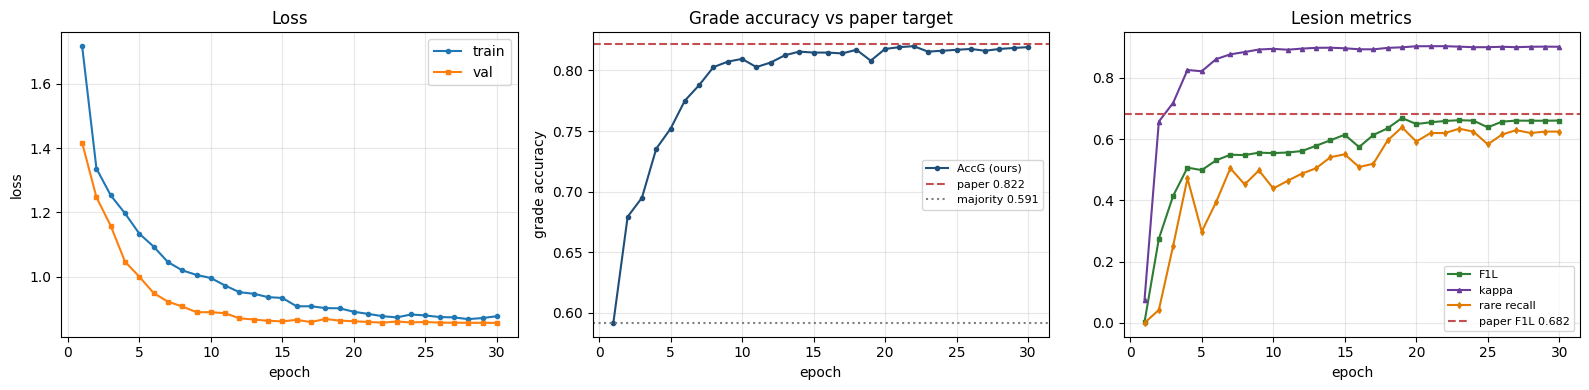

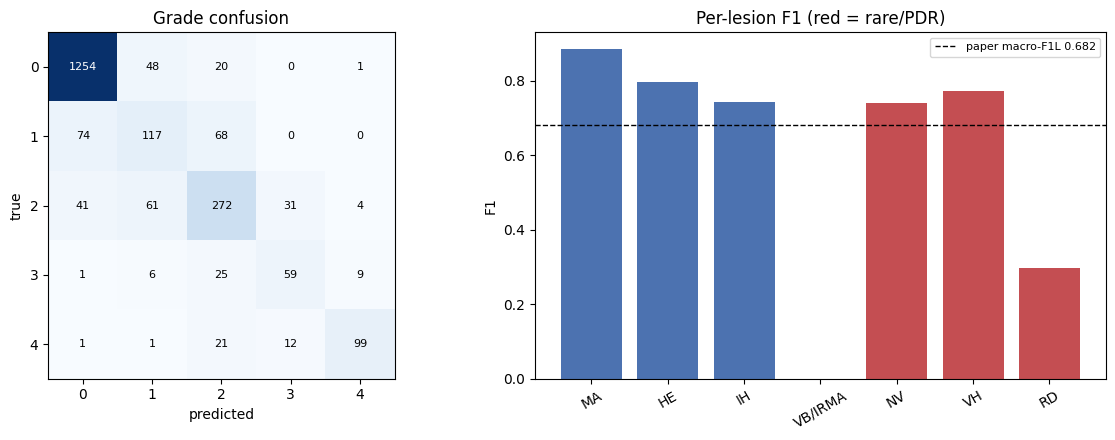

In [104]:
# ==============================================================================
# PLOTS -- training curves against the paper target, confusion matrix, per-lesion F1
# ==============================================================================
import matplotlib.pyplot as plt

log_csv = os.path.join(DIRS["logs"], f"train_{CFG['tag']}.csv")
if os.path.exists(log_csv):
    d = pd.read_csv(log_csv)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(d["epoch"], d["train_loss"], marker="o", ms=3, label="train")
    ax[0].plot(d["epoch"], d["val_loss"], marker="s", ms=3, label="val")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend()
    ax[0].set_title("Loss"); ax[0].grid(alpha=.3)

    ax[1].plot(d["epoch"], d["AccG"], marker="o", ms=3, color="#1f4e79", label="AccG (ours)")
    ax[1].axhline(0.822, ls="--", color="#C44E52", label="paper 0.822")
    ax[1].axhline(0.591, ls=":", color="gray", label="majority 0.591")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("grade accuracy"); ax[1].legend(fontsize=8)
    ax[1].set_title("Grade accuracy vs paper target"); ax[1].grid(alpha=.3)

    ax[2].plot(d["epoch"], d["F1L"], marker="s", ms=3, color="#2e7d32", label="F1L")
    ax[2].plot(d["epoch"], d["kappa"], marker="^", ms=3, color="#6a3d9a", label="kappa")
    ax[2].plot(d["epoch"], d["mean_rare_recall"], marker="d", ms=3, color="#e07b00",
               label="rare recall")
    ax[2].axhline(0.682, ls="--", color="#C44E52", label="paper F1L 0.682")
    ax[2].set_xlabel("epoch"); ax[2].legend(fontsize=8); ax[2].set_title("Lesion metrics")
    ax[2].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(DIRS["plots"], "curves.png"), dpi=120); plt.show()

if CFG["run_training"] and "gm" in dir():
    cm = np.array(gm["confusion_matrix"])
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    im = ax[0].imshow(cm, cmap="Blues")
    for i in range(5):
        for j in range(5):
            ax[0].text(j, i, cm[i, j], ha="center", va="center",
                       color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true"); ax[0].set_title("Grade confusion")
    ax[0].set_xticks(range(5)); ax[0].set_yticks(range(5))

    f1s = [lmA["per_lesion"][k]["f1"] for k in LESION_NAMES]
    cols = ["#4C72B0"] * 4 + ["#C44E52"] * 3
    ax[1].bar(LESION_NAMES, f1s, color=cols)
    ax[1].axhline(0.682, ls="--", color="k", lw=1, label="paper macro-F1L 0.682")
    ax[1].set_ylabel("F1"); ax[1].set_title("Per-lesion F1 (red = rare/PDR)")
    ax[1].tick_params(axis="x", rotation=30); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.savefig(os.path.join(DIRS["plots"], "test_breakdown.png"), dpi=120)
    plt.show()

---
# Results & discussion

**How to read the comparison table.** `OK` means the paper's value falls inside our 95% bootstrap
confidence interval, i.e. a statistical match on 2,225 test images (the CI half-width on accuracy is
roughly +/-1.6 points, so 0.815 and 0.822 are the same result).

**Why `AccL` is element-wise (Hamming) accuracy.** 13.97% of the 7-label matrix is positive, so a model
that predicts "no lesion" everywhere already scores **0.860**. The paper's 0.951 sits about 9 points
above that floor. Exact-match (all 7 labels simultaneously correct) would land far lower, so Hamming is
the only reading consistent with 0.951. The old notebook's ~0.89 was barely above the trivial floor —
another symptom of the untrained backbone.

**Why the headline row uses unweighted losses and a fixed 0.5 threshold.** Both paper targets are
*accuracy* metrics, and plain CE/BCE is what maximises accuracy under imbalance. Class weighting or
threshold tuning raises macro-F1 while lowering accuracy, which would make the comparison unreadable.
The tuned-threshold row is reported separately as a clinical-operating-point variant, on the same
trained model, with thresholds fitted on validation only.

**Deviations from the paper, stated honestly.**
- `fc_norm` is initialised from the checkpoint's encoder LayerNorm rather than randomly (RETFound
  discards it). One line, strictly better than random, noted here for completeness.
- The paper does not state whether grade and lesion were trained jointly or as two single-task models;
  this notebook trains them jointly, which is also what the rest of this project does.
- The paper does not state which F1 averaging it used, so all variants are printed.

# Comparison with the previous run

| | old (`findings/train_retfound.ipynb`) | this notebook |
|---|---|---|
| Pretrained weights | **4 / 294 tensors loaded** (silent failure) | verified load, hard-fails below 95% |
| Effective model | randomly-initialised ViT-L | RETFound MAE ViT-L |
| Freezing | freeze loop was a **no-op** (`int("ln_1")` raised) | full fine-tune, 0 frozen params, printed and asserted |
| Resolution | 224 | **512** (paper protocol), pos-embed interpolated |
| Split | random 80/20, test used as validation | **official `tr`/`ts`**, separate stratified val carve |
| LR schedule | none (flat 5e-5) | layer-wise decay 0.65 + warmup + cosine |
| Seed | none | fixed |
| Metrics | accuracy only | AccG/F1G/AccL/F1L + kappa, AUROC, PR-AUC, rare recall, CIs |
| Recovery | none | per-epoch checkpoint -> Kaggle Dataset, auto-resume |
| **Grade accuracy** | **0.665** | *(filled in by the run)* |

# Limitations & next steps

- Single seed. A publication-grade claim needs >=3 seeds with a paired significance test.
- If `AccG` lands short of the target while `AccL` is on target, the most likely cause is the joint
  multi-task setup; try `grade_only` first.
- If the 512 run underperforms a quick 224 control, suspect the position-embedding interpolation or
  the LR for the larger token count, not the weights.
- The tuned-threshold row is the better clinical operating point but is *not* the comparability row.